In [ ]:
import h5py
import numpy as np

path = "/home/arpit/test_projects/mimicgen/datasets/generated_data_mimicgen_format/core_datasets_og/r1_dishes_away_ablation_only_soft/demo_src_r1_dishes_away_task_D0/demo.hdf5"
f1 = h5py.File(path, "r")

path = "/home/arpit/test_projects/mimicgen/datasets/generated_data_mimicgen_format/core_datasets_og/r1_tidy_table_momagen/demo_src_r1_tidy_table_task_D2/demo.hdf5"
f2 = h5py.File(path, "r")

In [23]:
left_arm_joints = np.array([10, 12, 14, 16, 18, 20])
right_arm_joints = np.array([11, 13, 15, 17, 19, 21])
base_joints = np.array([0, 1, 5])
torso_joints = np.array([6, 7, 8,9])

In [24]:
# For all joints
num_demos = len(f1["data"].keys())
data1 = []
for i in range(num_demos):
    if i == 0:
        data1 = np.array(f1["data"][f"demo_{i}"]["obs"]["joint_qpos"])
    else:
        data1 = np.concatenate((data1, f1["data"][f"demo_{i}"]["obs"]["joint_qpos"]), axis=0)

num_demos = len(f2["data"].keys())
data2 = []
for i in range(num_demos):
    if i == 0:
        data2 = np.array(f2["data"][f"demo_{i}"]["obs"]["joint_qpos"])
    else:
        data2 = np.concatenate((data2, f2["data"][f"demo_{i}"]["obs"]["joint_qpos"]), axis=0)

In [18]:
# # For left arm only
# num_demos = len(f1["data"].keys())
# data1 = []
# for i in range(num_demos):
#     if i == 0:
#         data1 = f1["data"][f"demo_{i}"]["obs"]["joint_qpos"][:, left_arm_joints]
#     else:
#         data1 = np.concatenate((data1, f1["data"][f"demo_{i}"]["obs"]["joint_qpos"][:, left_arm_joints]), axis=0)

In [33]:
from scipy.spatial.transform import Rotation as R

def pose_to_vector(pose_array: np.ndarray) -> np.ndarray:
    """
    Converts a batch of homogeneous transformation matrices (N, 4, 4)
    into (N, 6) vectors: [x, y, z, rx, ry, rz] where r is the rotation vector.
    """
    assert pose_array.ndim == 3 and pose_array.shape[1:] == (4, 4), \
        "Input must be of shape (N, 4, 4)"
    
    # Extract translation: shape (N, 3)
    translations = pose_array[:, :3, 3]
    
    # Extract rotations: shape (N, 3, 3)
    rotations = pose_array[:, :3, :3]
    
    # Convert rotation matrices to rotation vectors: shape (N, 3)
    rvecs = R.from_matrix(rotations).as_rotvec()
    
    # Concatenate translations and rotation vectors: shape (N, 6)
    return np.hstack((translations, rvecs))


# EEF poses
side = "left"
num_demos = len(f1["data"].keys())
data1 = []
for i in range(num_demos):
    if side =="left":
        res = np.array(f1["data"][f"demo_{i}"]["datagen_info"]["eef_pose"])[:, :4]
    elif side == "right":
        res = np.array(f1["data"][f"demo_{i}"]["datagen_info"]["eef_pose"])[:, 4:]
    
    res = pose_to_vector(res)
    if i == 0:
        data1 = res
    else:
        data1 = np.concatenate((data1, res), axis=0)

num_demos = len(f2["data"].keys())
data2 = []
for i in range(num_demos):
    if side =="left":
        res = np.array(f2["data"][f"demo_{i}"]["datagen_info"]["eef_pose"])[:, :4]
    elif side == "right":
        res = np.array(f2["data"][f"demo_{i}"]["datagen_info"]["eef_pose"])[:, 4:]
    
    res = pose_to_vector(res)
    if i == 0:
        data2 = res
    else:
        data2 = np.concatenate((data2, res), axis=0)

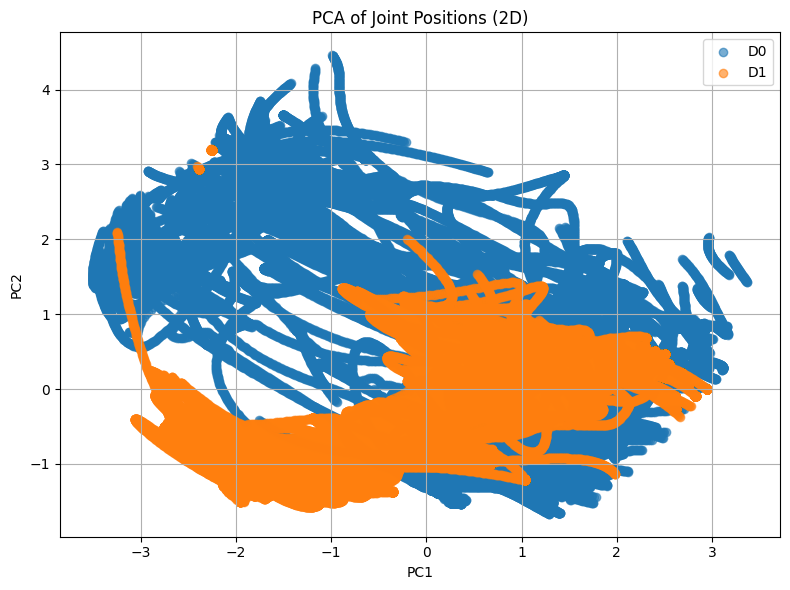

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


np.random.seed(0)
dataset1 = data1
dataset2 = data2

# Combine the datasets
combined_data = np.vstack([dataset1, dataset2])

# Run PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(combined_data)

# Split back for plotting
pca_dataset1 = pca_result[:len(dataset1)]
pca_dataset2 = pca_result[len(dataset1):]

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(pca_dataset1[:, 0], pca_dataset1[:, 1], label='D0', alpha=0.6)
plt.scatter(pca_dataset2[:, 0], pca_dataset2[:, 1], label='D1', alpha=0.6)
plt.title('PCA of Joint Positions (2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()